In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
train=pd.read_csv(r"C:\Users\Aaditya Saini\Desktop\Churn\data\train.csv")
test=pd.read_csv(r"C:\Users\Aaditya Saini\Desktop\Churn\data\test.csv")
sub=pd.read_csv(r"C:\Users\Aaditya Saini\Desktop\Churn\data\sample_submission.csv")

In [3]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  PaperlessBilling  594194 non-nu

In [5]:
num_cols=train.select_dtypes(include=np.number).columns.tolist()
cat_cols=train.select_dtypes(include="object").columns.tolist()

C:\Users\Aaditya Saini\AppData\Local\Temp\ipykernel_34796\469474389.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=train.select_dtypes(include="object").columns.tolist()


In [6]:
for i in cat_cols:
    print(train[i].value_counts())

gender
Female    298738
Male      295456
Name: count, dtype: int64
Partner
Yes    309554
No     284640
Name: count, dtype: int64
Dependents
No     414362
Yes    179832
Name: count, dtype: int64
PhoneService
Yes    557893
No      36301
Name: count, dtype: int64
MultipleLines
No                  283384
Yes                 274509
No phone service     36301
Name: count, dtype: int64
InternetService
Fiber optic    272386
DSL            181081
No             140727
Name: count, dtype: int64
OnlineSecurity
No                     289474
Yes                    163993
No internet service    140727
Name: count, dtype: int64
OnlineBackup
No                     250083
Yes                    203384
No internet service    140727
Name: count, dtype: int64
DeviceProtection
No                     247377
Yes                    206090
No internet service    140727
Name: count, dtype: int64
TechSupport
No                     288571
Yes                    164896
No internet service    140727
Name: count, dt

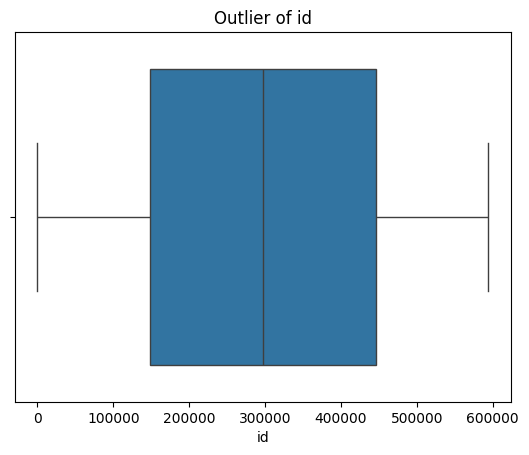

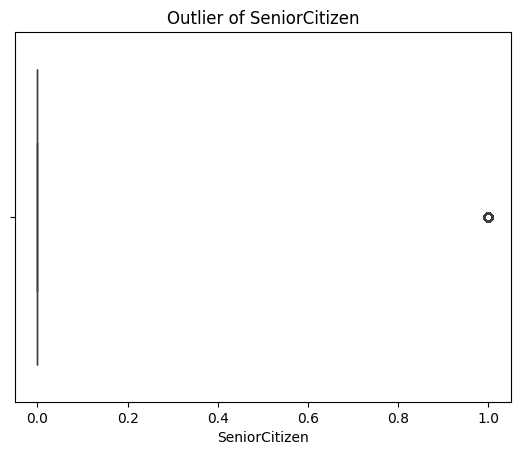

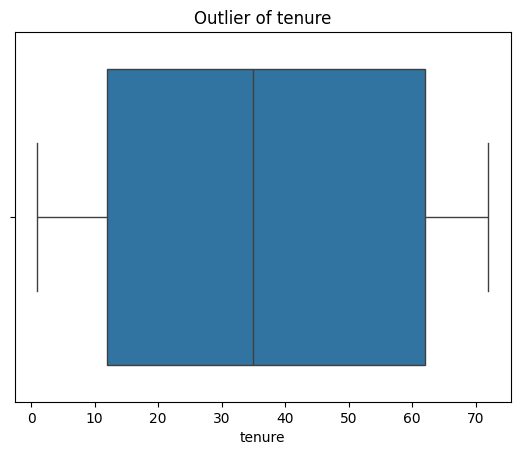

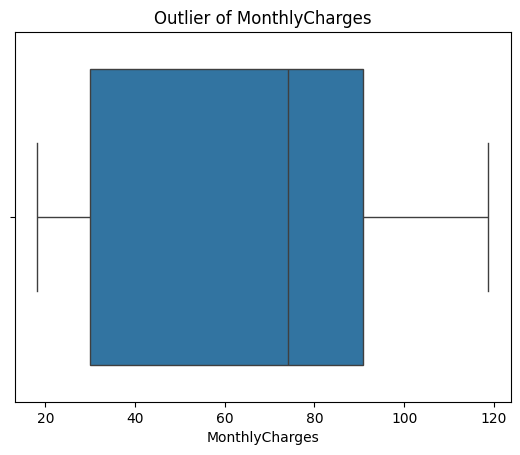

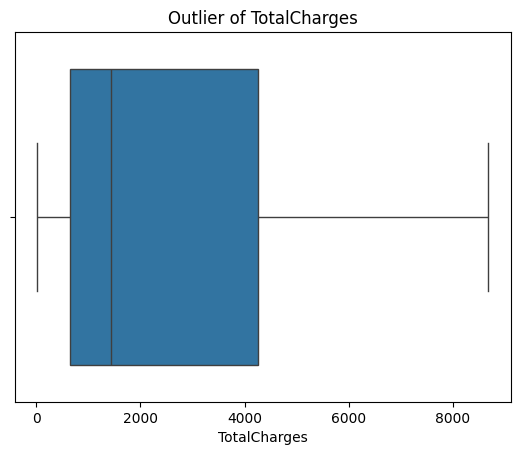

In [7]:
import matplotlib.pyplot as plt 
import seaborn as sns

for i in num_cols:
    plt.figure()
    sns.boxplot(x=train[i])
    plt.title(f"Outlier of {i}")
    plt.show()

In [8]:
train.drop("id",axis=1,inplace=True)
test.drop("id",axis=1,inplace=True)

In [9]:
num_cols.remove("id")

In [10]:
num_cols.remove("SeniorCitizen") 
'''removed because this is the feature we're trying to predict
error because theres churn is not a numerical column'''

"removed because this is the feature we're trying to predict\nerror because theres churn is not a numerical column"

In [11]:
cat_cols.remove("Churn")

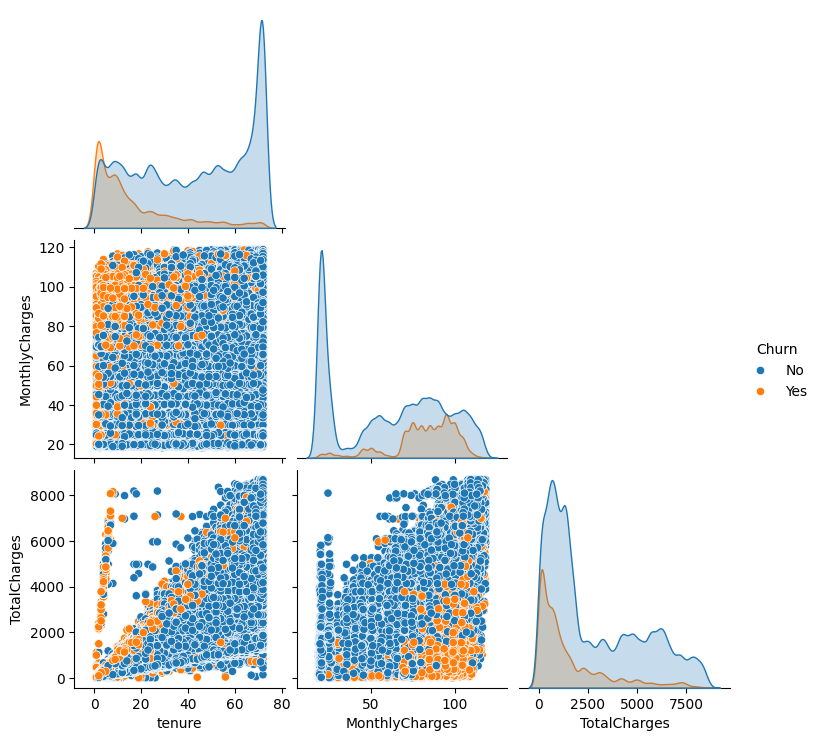

In [12]:
sns.pairplot(train[num_cols + ['Churn']], hue='Churn', corner=True)
plt.show()

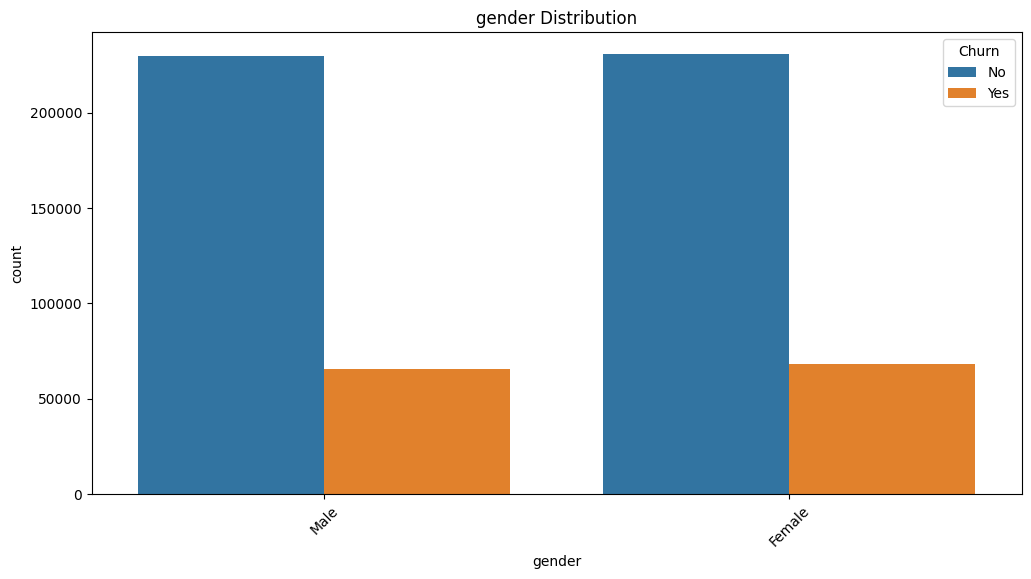

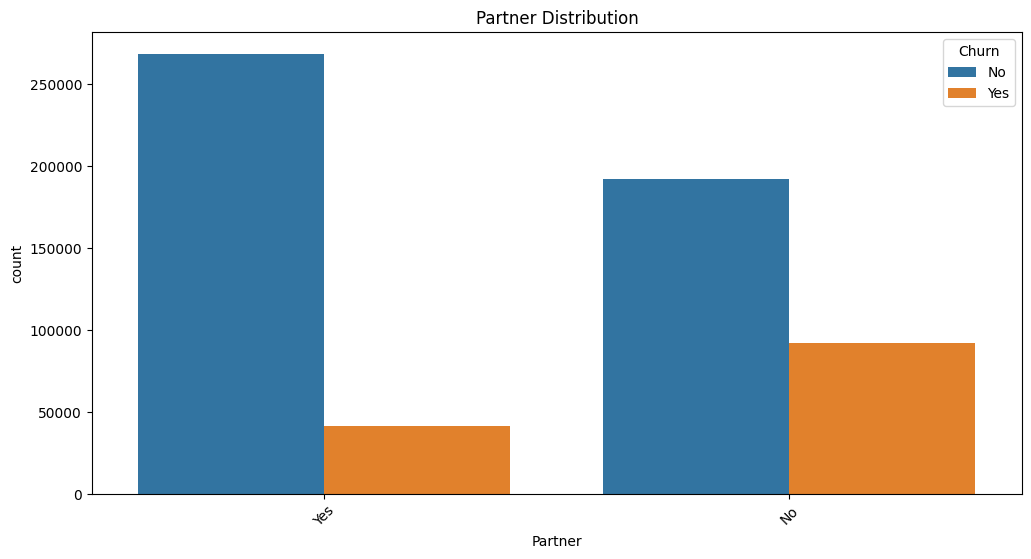

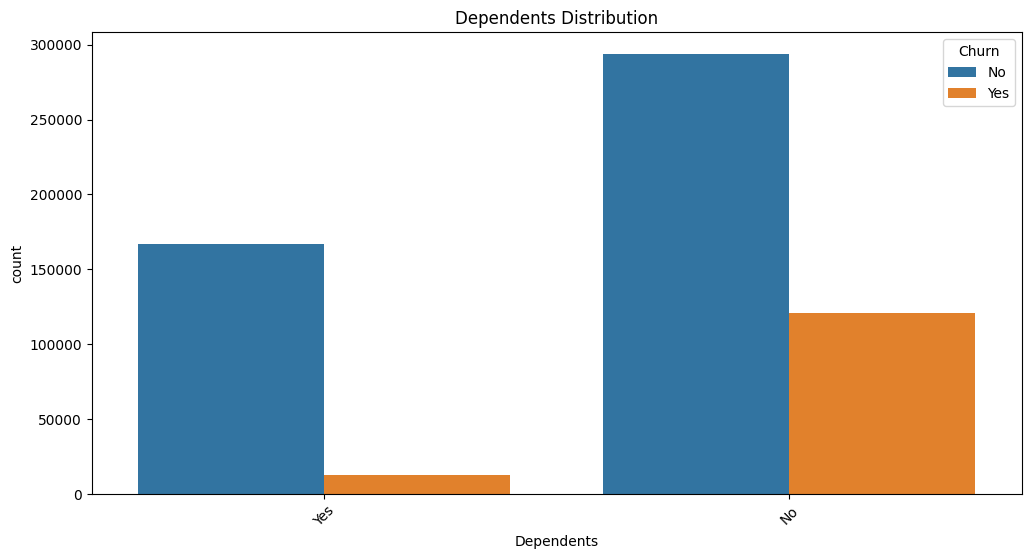

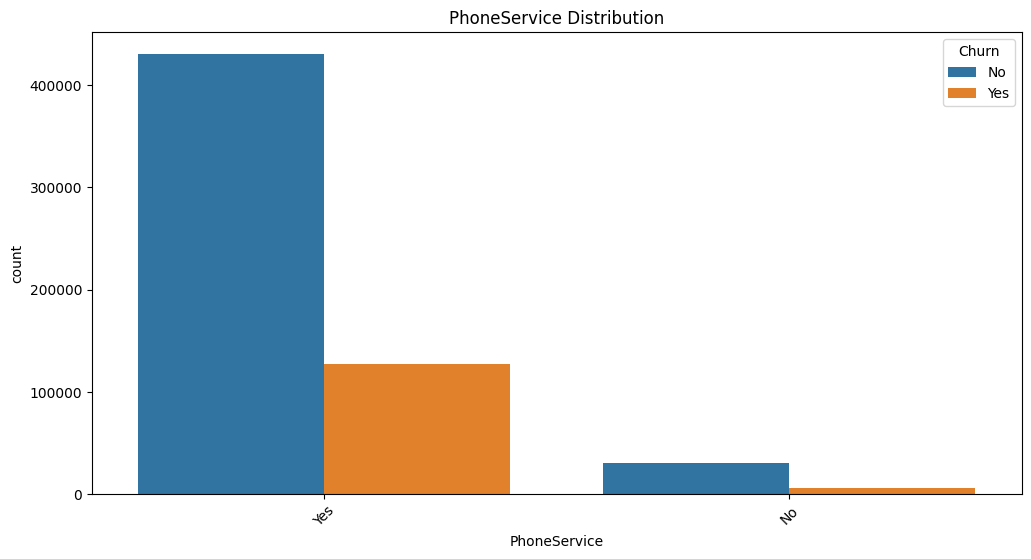

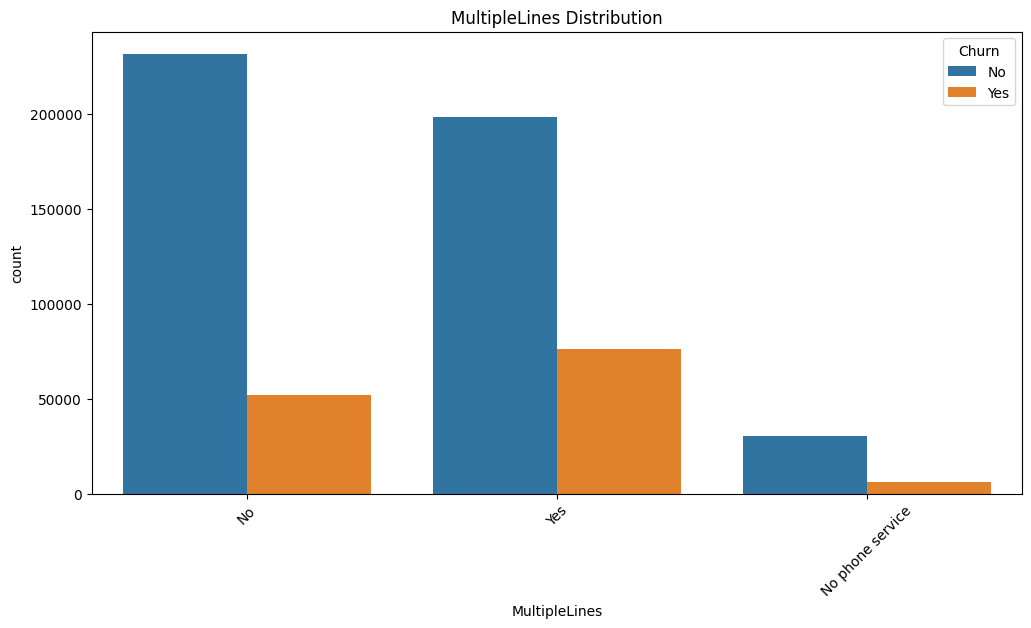

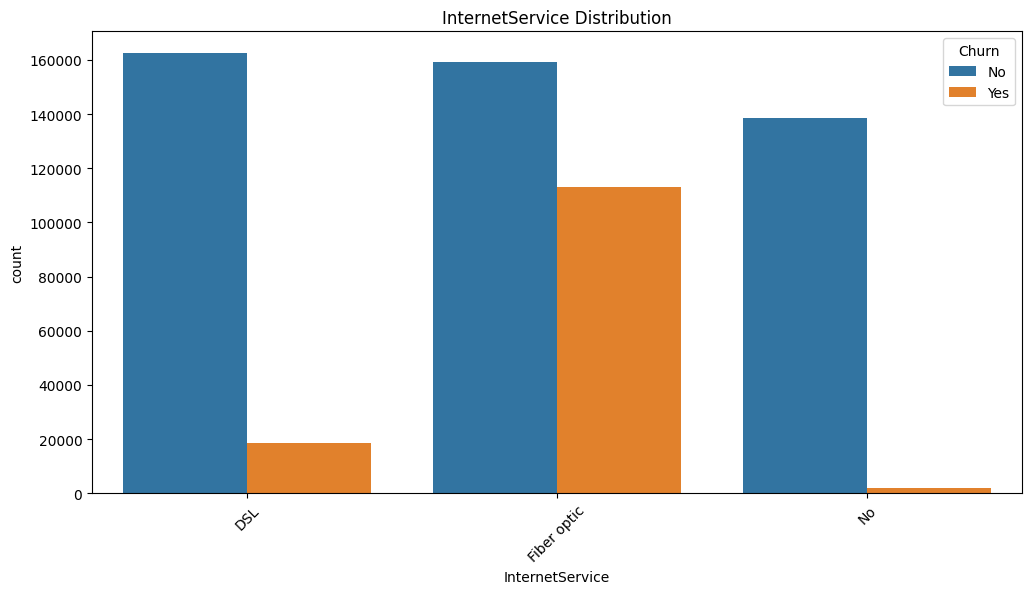

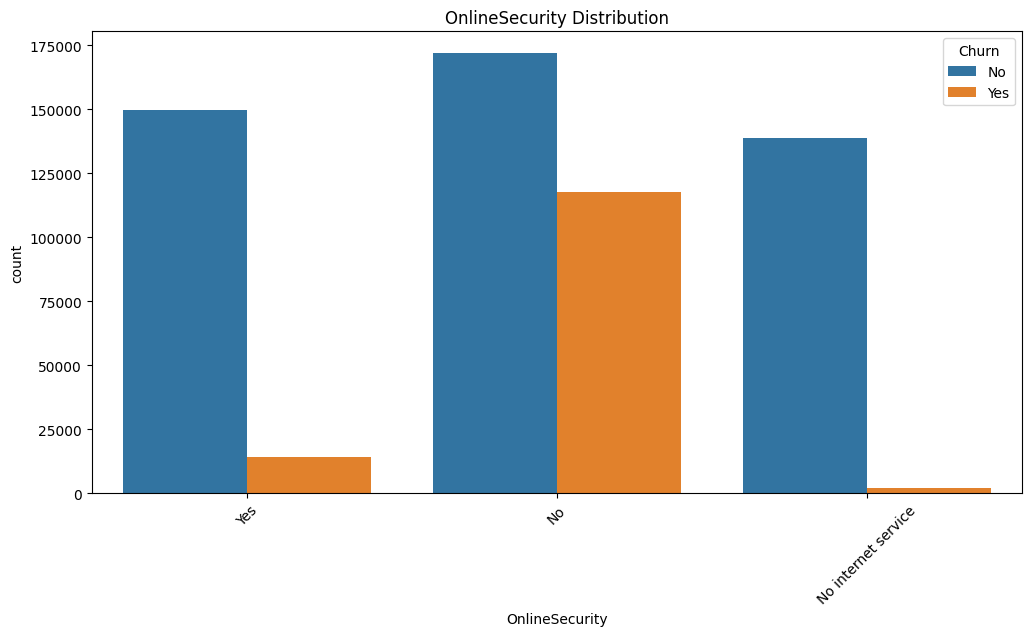

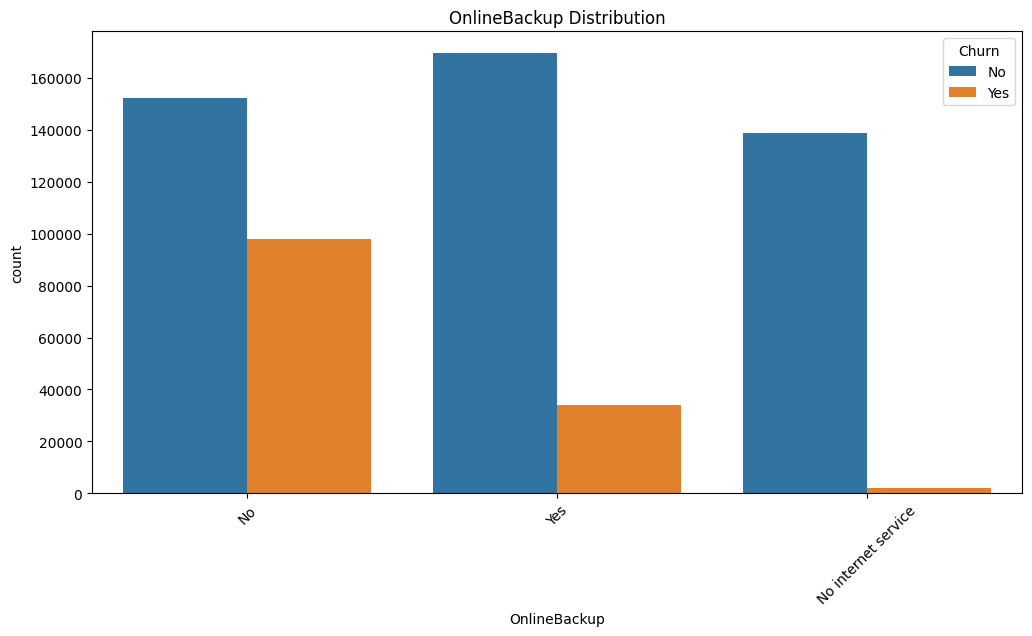

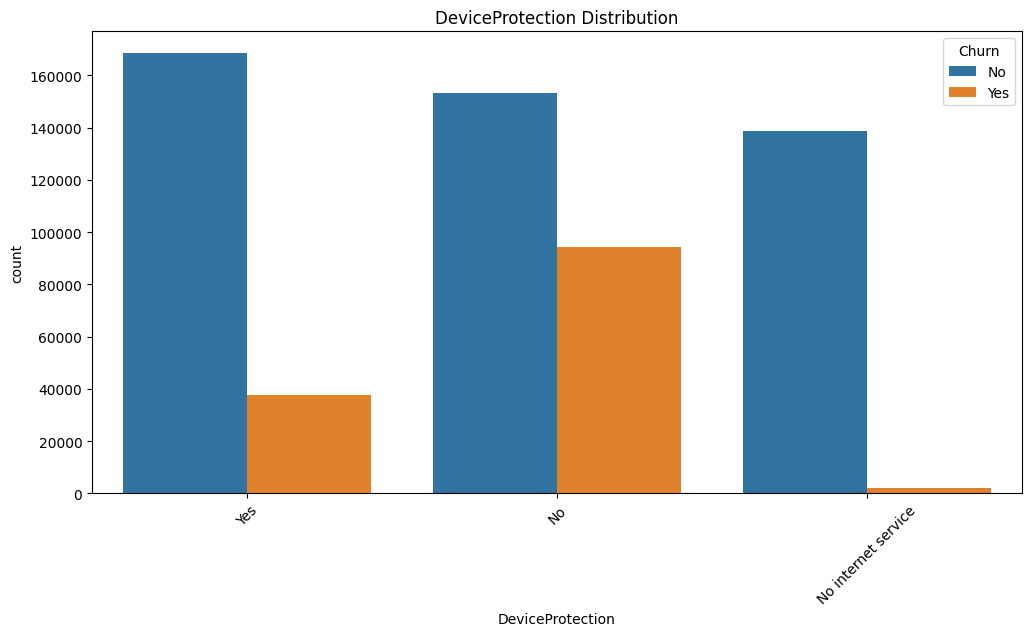

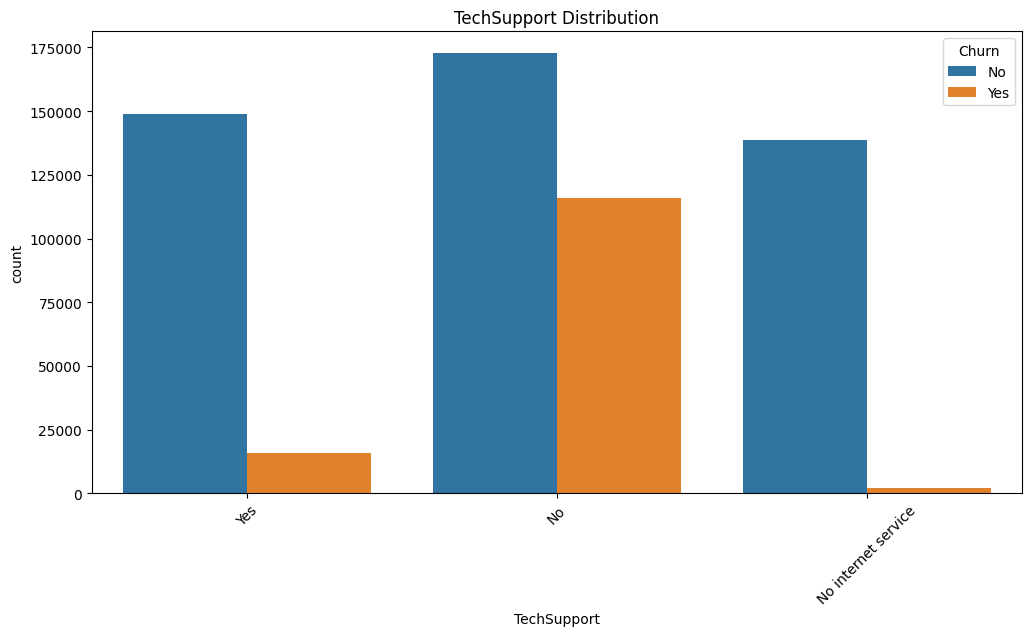

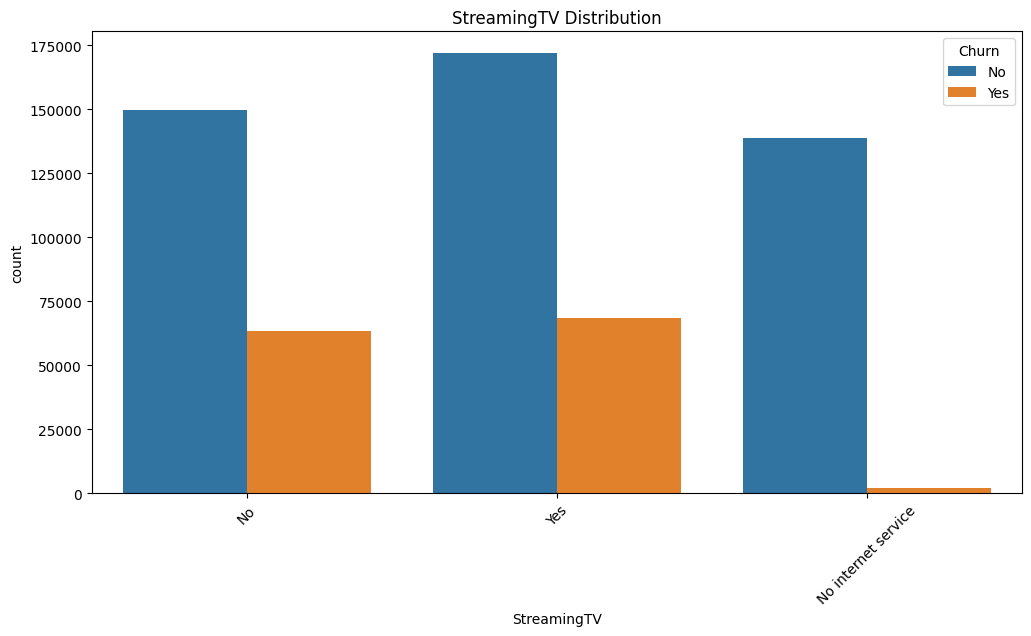

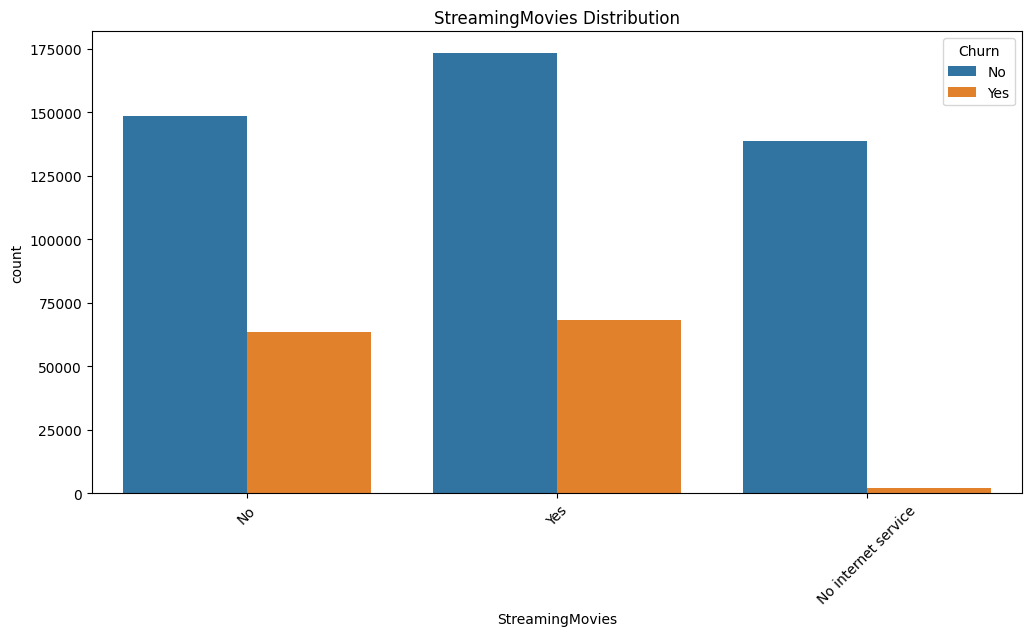

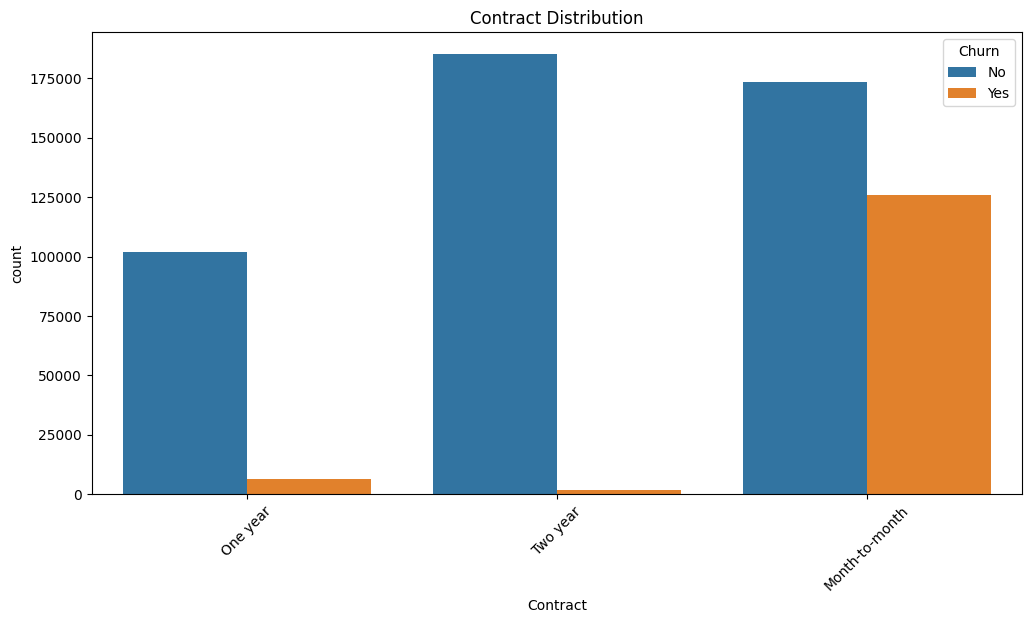

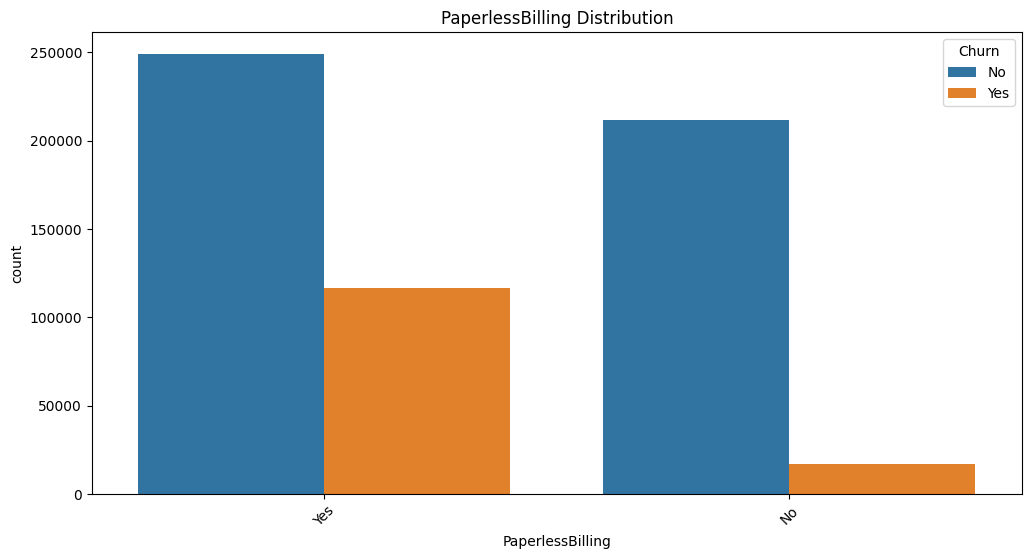

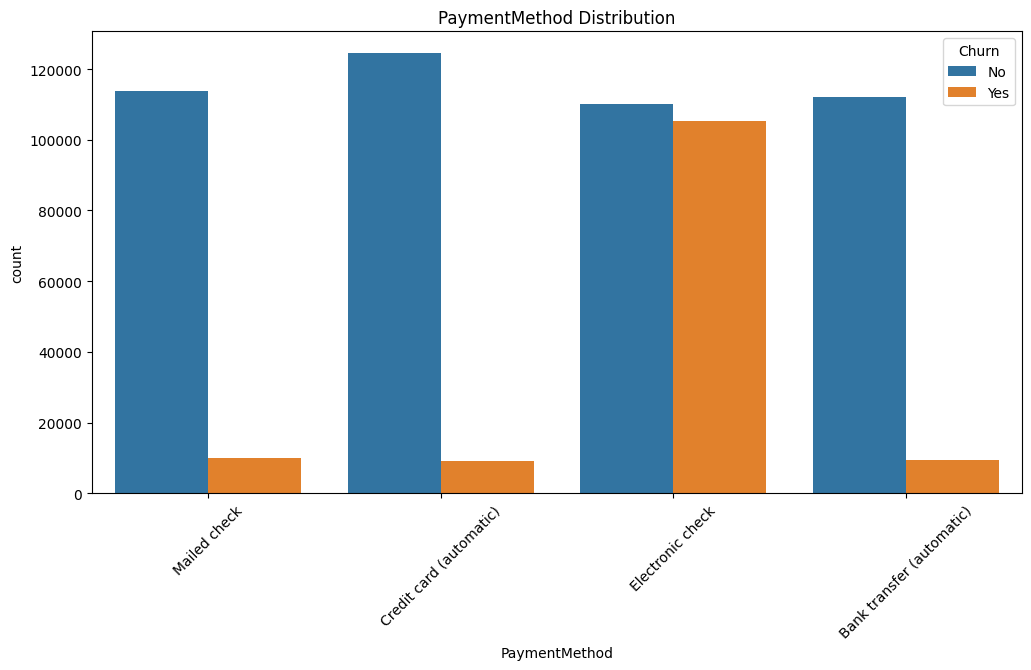

In [13]:
for i in cat_cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=train, x=i, hue='Churn')
    plt.title(f"{i} Distribution")
    plt.xticks(rotation=45)
    plt.show()

In [20]:
X = train.drop('Churn', axis=1)
y = train['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/100.2 MB 5.0 MB/s eta 0:00:20
    --------------------------------------- 2.1/100.2 MB 5.3 MB/s eta 0:00:19
    --------------------------------------- 2.1/100.2 MB 5.3 MB/s eta 0:00:19
    --------------------------------------- 2.1/100.2 MB 5.3 MB/s eta 0:00:19
    --------------------------------------- 2.1/100.2 MB 5.3 MB/s eta 0:00:19
   - -------------------------------------- 2.9/100.2 MB 2.2 MB/s eta 0:00:45
   - -------------------------------------- 4.2/100.2 MB 2.8 MB/s eta 0:00:35
   - -------------------------------------- 4.2/100.2 MB 2.8 MB/s eta 0:00:35
   - -------------------------------------- 4.7/100.2 MB 2.5 MB/s eta 0:00:39
   -- ------------------------------------- 5.8/100.2 MB 2.8 MB/s eta 0:00:35
   -- ------------------------------------- 5.8/100.2 MB 2.8 MB/s eta 0:00:35


In [17]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)])

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)


'''OOF stands for "Out-Of-Fold" predictions. 
These are empty arrays being created to store predictions from each model during cross-validation.'''
oof_xgb = np.zeros(len(X_train))
oof_cat = np.zeros(len(X_train))
oof_gbc = np.zeros(len(X_train))

test_xgb = np.zeros(len(test))
test_cat = np.zeros(len(test))
test_gbc = np.zeros(len(test))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"--- Fold {fold+1} ---")

    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    
    xgb_pipe = Pipeline([
        ('prep', preprocessor),
        ('model', XGBClassifier(
            n_estimators=4000,
            max_depth=8,
            subsample=0.8,
            colsample_bytree=0.8,
            learning_rate=0.01,
            eval_metric='auc',
            random_state=42,
            verbosity=0,
            device='cuda'
        ))
    ])    

    cat_pipe = Pipeline([
        ('prep', preprocessor),
        ('model', CatBoostClassifier(
            iterations=4000,
            depth=8,
            bootstrap_type='Bernoulli',
            subsample=0.8,
            learning_rate=0.01,
            loss_function='Logloss',
            random_state=42,
            verbose=0,
            task_type ='GPU',    
            devices= '0',
            eval_metric='AUC'
        ))
    ])

    gbc_pipe = Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingClassifier(
            n_estimators=2000,
            max_depth=7,
            subsample=0.8,
            learning_rate=0.02,
            random_state=42
        ))
    ])

    gbc_pipe.fit(X_tr, y_tr)
    xgb_pipe.fit(X_tr, y_tr)
    cat_pipe.fit(X_tr, y_tr)
    

    oof_xgb[val_idx] = xgb_pipe.predict_proba(X_val)[:, 1]
    oof_cat[val_idx] = cat_pipe.predict_proba(X_val)[:, 1]
    oof_gbc[val_idx] = gbc_pipe.predict_proba(X_val)[:, 1]

    test_xgb += xgb_pipe.predict_proba(test)[:, 1] / n_splits
    test_cat += cat_pipe.predict_proba(test)[:, 1] / n_splits
    test_gbc += gbc_pipe.predict_proba(test)[:, 1] / n_splits

--- Fold 1 ---


Default metric period is 5 because AUC is/are not implemented for GPU


--- Fold 2 ---


Default metric period is 5 because AUC is/are not implemented for GPU


--- Fold 3 ---


Default metric period is 5 because AUC is/are not implemented for GPU


--- Fold 4 ---


Default metric period is 5 because AUC is/are not implemented for GPU


--- Fold 5 ---


In [ ]:
best_auc = 0
best_weights = None


for w_xgb in np.arange(0, 1.01, 0.05):
    for w_cat in np.arange(0, 1.01 - w_xgb, 0.05):
        w_gbc = 1.0 - w_xgb - w_cat
        
        blend_oof = (w_xgb * oof_xgb) + (w_cat * oof_cat) + (w_gbc * oof_gbc)
        
        auc = roc_auc_score(y_train, blend_oof)
        
        if auc > best_auc:
            best_auc = auc
            best_weights = (w_xgb, w_cat, w_gbc)

ValueError: unknown format is not supported

In [17]:
from sklearn.isotonic import IsotonicRegression

w_xgb, w_cat, w_gbc = best_weights

ensemble_oof = (
    w_xgb * oof_xgb +
    w_cat * oof_cat +
    w_gbc * oof_gbc
)

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(ensemble_oof, y_train)

IsotonicRegression(out_of_bounds='clip')

In [18]:
ensemble_test = (
    w_xgb * test_xgb +
    w_cat * test_cat +
    w_gbc * test_gbc
)

probs = iso.transform(ensemble_test)

In [19]:
sub["Churn"]=probs

In [20]:
sub.to_csv("submission.csv",index=False)